### 10k rows, reduced cardinality, but terrible results.
We're looking at roughly ~10k rows of data and some cardinality reduction for the exp_component category when attempting one-hot encoding. But, negative r^2 values are pretty terrible.

In [1]:
# Environment work around to get matplotlib/seaborn
import sys
sys.path.append('/home/Janice.Kim/work/epmt/misc/jk_py37')

In [2]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

import csv
import pandas as pd
from pprint import pprint

In [3]:
#csv_path = "/home/Janice.Kim/work/epmt/epmt/jk_data.csv"
#csv_path = "/home/Janice.Kim/work/epmt/jk_data_play.csv"
csv_path = "/home/Janice.Kim/work/epmt/jk_data_play_10k.csv"
target_col = "cpu_time" # ground truth column

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("Columns:\n", df.dtypes)

Shape: (10000, 9)
Columns:
 exp_component      object
exp_fre_mod        object
exp_name           object
exp_time            int64
exp_platform       object
exp_target         object
exp_seg_months    float64
script_name        object
cpu_time          float64
dtype: object


In [4]:
# Find the NaNs
df.isna().sum()

exp_component       1
exp_fre_mod       661
exp_name            0
exp_time            0
exp_platform        0
exp_target          0
exp_seg_months    661
script_name         0
cpu_time            0
dtype: int64

In [5]:
df = df.dropna(subset=['exp_component'])
df = df.drop(columns=['exp_fre_mod', 'exp_seg_months'])
df.isna().sum()

exp_component    0
exp_name         0
exp_time         0
exp_platform     0
exp_target       0
script_name      0
cpu_time         0
dtype: int64

In [6]:
df.head()

,exp_component,exp_name,exp_time,exp_platform,exp_target,script_name,cpu_time
0,river_cubic,SPEAR_c384_OM4p08_Control_1990_A13,1000101,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_river_cubic...,103951272.0
1,atmos_scalar,SPEAR_c384_OM4p08_Control_1990_A13,1000101,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_atmos_scala...,12713067.0
2,ocean_scalar,SPEAR_c384_OM4p08_Control_1990_A13,990101,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_ocean_scala...,22186898.0
3,ocean_daily_1deg,SPEAR_c384_OM4p08_Control_1990_A13,990101,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_ocean_daily...,5032113.0
4,ice_1deg,SPEAR_c384_OM4p08_Control_1990_A13,990101,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_ice_1deg_00...,72152950.0


In [7]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
category_cols = df.select_dtypes(exclude="number").columns.tolist()

print("# numeric columns:", len(numeric_cols))
print("# category columns:", len(category_cols))

# numeric columns: 2
# category columns: 5


Text(0.5, 0.98, 'Numeric Feature Distributions')

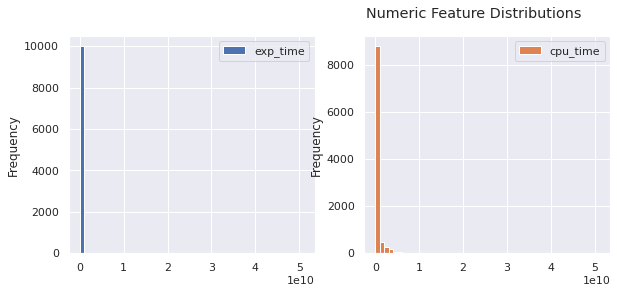

In [8]:
axes = df[numeric_cols].plot(kind='hist', bins=50, subplots=True, layout=(1,3), figsize=(15,4))
plt.suptitle("Numeric Feature Distributions")

In [9]:
from sklearn.preprocessing import OneHotEncoder

print("Category Columns:", category_cols)
df[category_cols].head()

Category Columns: ['exp_component', 'exp_name', 'exp_platform', 'exp_target', 'script_name']


,exp_component,exp_name,exp_platform,exp_target,script_name
0,river_cubic,SPEAR_c384_OM4p08_Control_1990_A13,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_river_cubic...
1,atmos_scalar,SPEAR_c384_OM4p08_Control_1990_A13,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_atmos_scala...
2,ocean_scalar,SPEAR_c384_OM4p08_Control_1990_A13,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_ocean_scala...
3,ocean_daily_1deg,SPEAR_c384_OM4p08_Control_1990_A13,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_ocean_daily...
4,ice_1deg,SPEAR_c384_OM4p08_Control_1990_A13,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_ice_1deg_00...


In [10]:
category_cols_mod = ['exp_component', 'exp_platform', 'exp_target'] # keeping only a few without NaNs
ohe = OneHotEncoder(sparse=False)
ohe_data = ohe.fit_transform(df[category_cols_mod])
ohe_cols = ohe.get_feature_names(category_cols_mod)
df_categorical = pd.DataFrame(ohe_data, columns=ohe_cols)
df_categorical.head()

,exp_component_LUmip_month_crp,exp_component_LUmip_month_psl,exp_component_LUmip_month_pst,exp_component_LUmip_refined,exp_component_aerosol_cmip,exp_component_aerosol_cmip_2deg,exp_component_aerosol_hourly_cmip,exp_component_analysis,exp_component_atmos,exp_component_atmos_4xdaily,...,exp_target_prod-hdf5,exp_target_prod-openmp,exp_target_repro,exp_target_repro-openmp,exp_target_test10_01_15_2026,exp_target_test11_01_15_2026,exp_target_test12_01_16_2026,exp_target_test13_01_16_2026,exp_target_test8_01_14_2026,exp_target_test9_01_15_2026
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


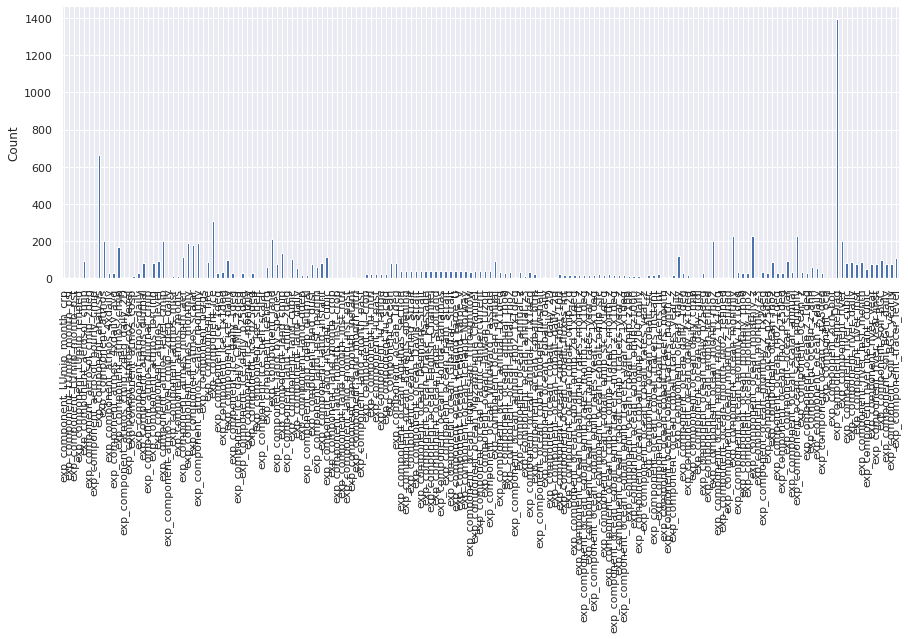

In [11]:
def plot_one_category(df_categorical, single_category):
    startswith = f"{single_category}_"
    cols = [c for c in df_categorical.columns if c.startswith(startswith)]
    df_categorical[cols].sum().plot(kind='bar', figsize=(15,5))
    plt.ylabel('Count')
    plt.show()
    
plot_one_category(df_categorical, "exp_component")

In [12]:
# Try to reduce the cardinality of the exp_component
df['exp_component'] = (
    df['exp_component'].str.replace(r'^(atmos|ocean|land|river|aerosol|soil)_.*', r'\1', regex=True)
)
df.head()

,exp_component,exp_name,exp_time,exp_platform,exp_target,script_name,cpu_time
0,river,SPEAR_c384_OM4p08_Control_1990_A13,1000101,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_river_cubic...,103951272.0
1,atmos,SPEAR_c384_OM4p08_Control_1990_A13,1000101,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_atmos_scala...,12713067.0
2,ocean,SPEAR_c384_OM4p08_Control_1990_A13,990101,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_ocean_scala...,22186898.0
3,ocean,SPEAR_c384_OM4p08_Control_1990_A13,990101,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_ocean_daily...,5032113.0
4,ice_1deg,SPEAR_c384_OM4p08_Control_1990_A13,990101,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_ice_1deg_00...,72152950.0


In [13]:
ohe_data = ohe.fit_transform(df[category_cols_mod])
ohe_cols = ohe.get_feature_names(category_cols_mod)
df_categorical = pd.DataFrame(ohe_data, columns=ohe_cols)
df_categorical.head()

,exp_component_LUmip_month_crp,exp_component_LUmip_month_psl,exp_component_LUmip_month_pst,exp_component_LUmip_refined,exp_component_aerosol,exp_component_analysis,exp_component_atmos,exp_component_bergs,exp_component_fire,exp_component_ice,...,exp_target_prod-hdf5,exp_target_prod-openmp,exp_target_repro,exp_target_repro-openmp,exp_target_test10_01_15_2026,exp_target_test11_01_15_2026,exp_target_test12_01_16_2026,exp_target_test13_01_16_2026,exp_target_test8_01_14_2026,exp_target_test9_01_15_2026
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


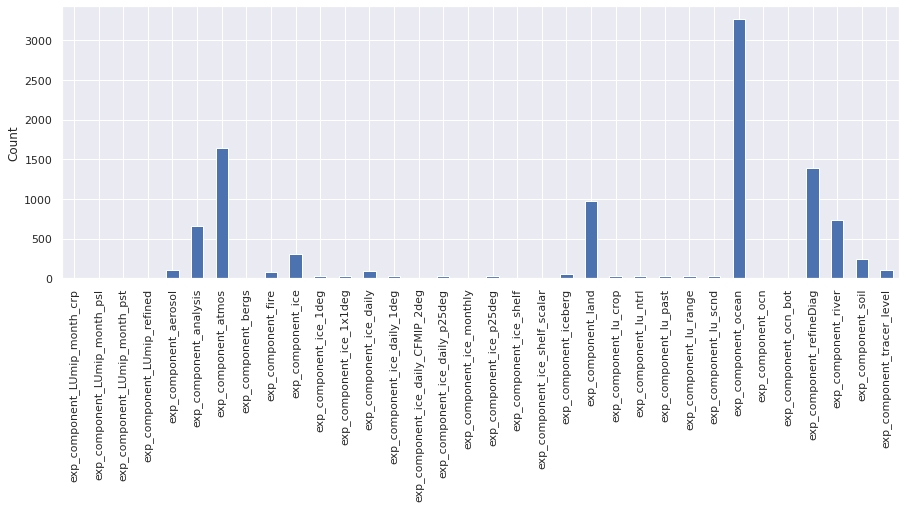

In [14]:
# Plot again but with reduced cardinality
plot_one_category(df_categorical, "exp_component")

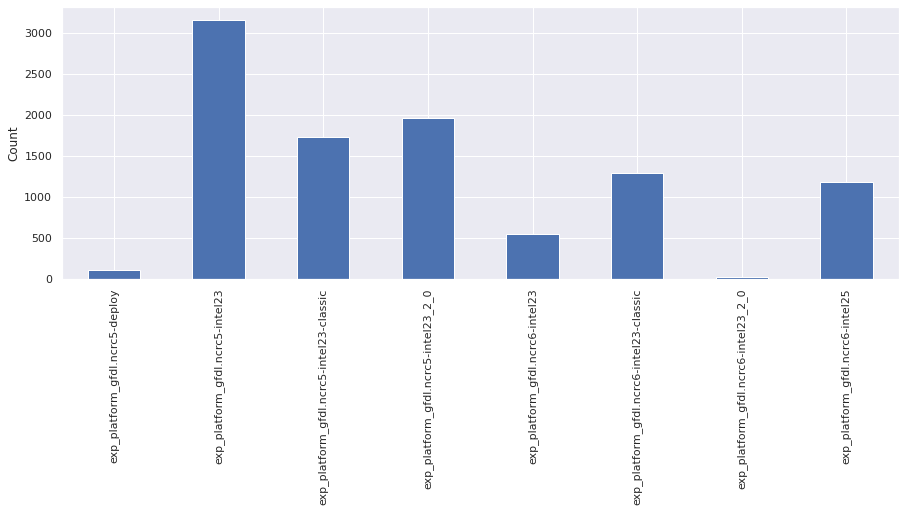

In [15]:
plot_one_category(df_categorical, "exp_platform")

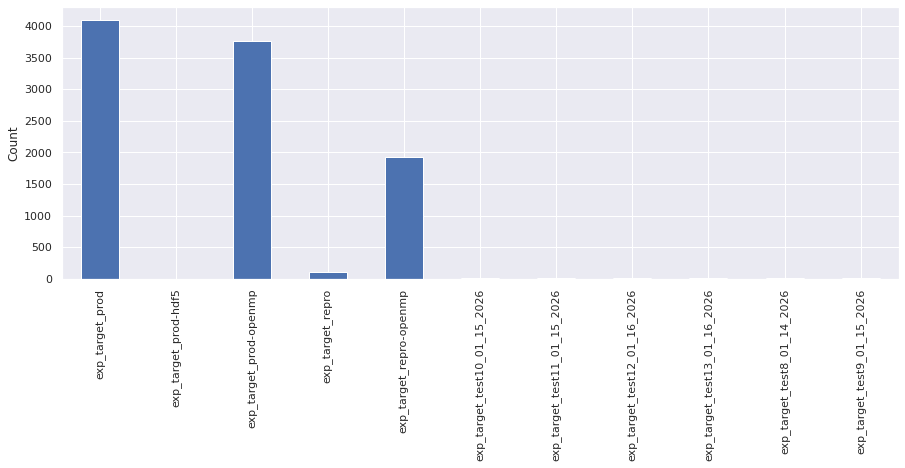

In [16]:
plot_one_category(df_categorical, "exp_target")

In [17]:
## Put it together

In [18]:
df_full = pd.concat(
    [df[numeric_cols], df_categorical],
    axis=1
)

df_full = df_full.dropna()
df_full.head()

,exp_time,cpu_time,exp_component_LUmip_month_crp,exp_component_LUmip_month_psl,exp_component_LUmip_month_pst,exp_component_LUmip_refined,exp_component_aerosol,exp_component_analysis,exp_component_atmos,exp_component_bergs,...,exp_target_prod-hdf5,exp_target_prod-openmp,exp_target_repro,exp_target_repro-openmp,exp_target_test10_01_15_2026,exp_target_test11_01_15_2026,exp_target_test12_01_16_2026,exp_target_test13_01_16_2026,exp_target_test8_01_14_2026,exp_target_test9_01_15_2026
0,1000101.0,103951272.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1000101.0,12713067.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,990101.0,22186898.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,990101.0,5032113.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,990101.0,72152950.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


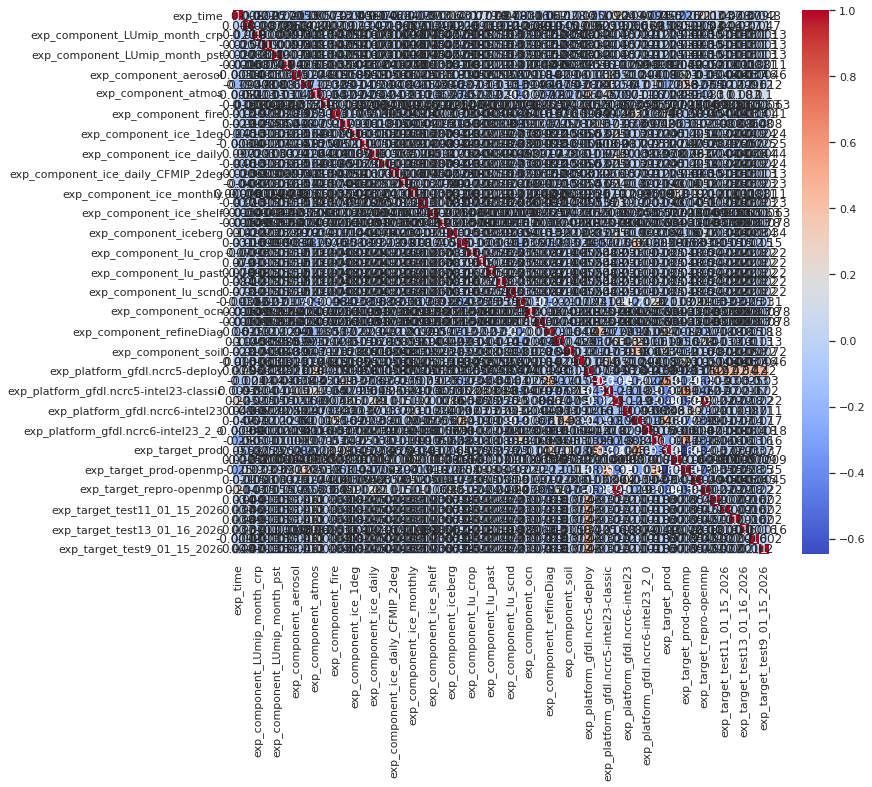

In [19]:
corr = df_full.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [21]:
target = 'cpu_time'

X = df_full.drop(target, axis=1)
y = df_full[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [22]:
# Find MOAR NaNs
X_train.isna().sum()

exp_time                                   0
exp_component_LUmip_month_crp              0
exp_component_LUmip_month_psl              0
exp_component_LUmip_month_pst              0
exp_component_LUmip_refined                0
exp_component_aerosol                      0
exp_component_analysis                     0
exp_component_atmos                        0
exp_component_bergs                        0
exp_component_fire                         0
exp_component_ice                          0
exp_component_ice_1deg                     0
exp_component_ice_1x1deg                   0
exp_component_ice_daily                    0
exp_component_ice_daily_1deg               0
exp_component_ice_daily_CFMIP_2deg         0
exp_component_ice_daily_p25deg             0
exp_component_ice_monthly                  0
exp_component_ice_p25deg                   0
exp_component_ice_shelf                    0
exp_component_ice_shelf_scalar             0
exp_component_iceberg                      0
exp_compon

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 3244931858765735936.00
R-squared Score: 0.03


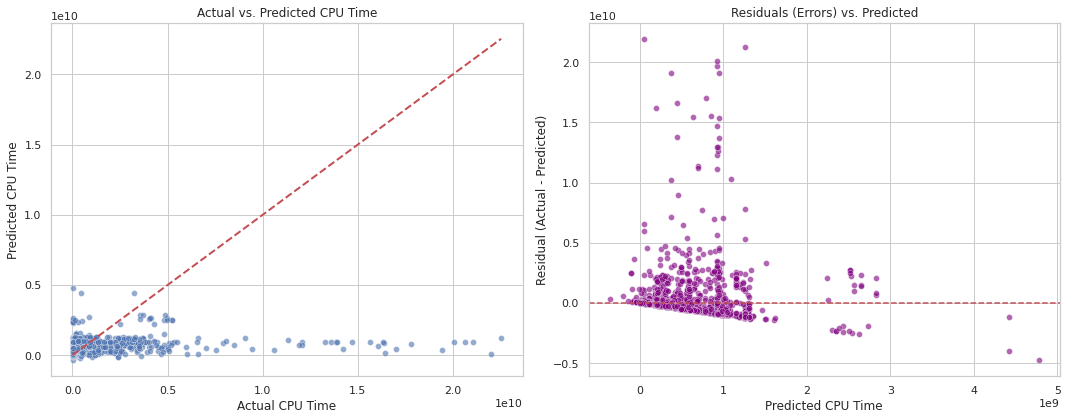

In [24]:
# TODO Code for the following was generated by Gemini. It will be inspected more carefully

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Actual vs Predicted ---
sns.scatterplot(x=y_test, y=predictions, ax=ax1, alpha=0.6)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
ax1.set_title('Actual vs. Predicted CPU Time')
ax1.set_xlabel('Actual CPU Time')
ax1.set_ylabel('Predicted CPU Time')

# --- Plot 2: Residual Plot ---
residuals = y_test - predictions
sns.scatterplot(x=predictions, y=residuals, ax=ax2, color='purple', alpha=0.6)
ax2.axhline(y=0, color='r', linestyle='--') # Zero-error line
ax2.set_title('Residuals (Errors) vs. Predicted')
ax2.set_xlabel('Predicted CPU Time')
ax2.set_ylabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()

In [25]:
## RandomForest Example --- won't work here... TODO try again with different env

In [26]:
#from sklearn.ensemble import RandomForestRegressor

In [27]:
## SVM Regression Example

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

In [29]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
svr_model = SVR(kernel="rbf", C=10, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)

SVR(C=10, cache_size=200, coef0=0.0, degree=3, epsilon=0.1, gamma='scale',
    kernel='rbf', max_iter=-1, shrinking=True, tol=0.001, verbose=False)

In [30]:
# predictions
y_pred = model.predict(X_test_scaled)

In [31]:
mean_squared_error(y_test, y_pred, squared=False)

4347171076.989157

In [32]:
r2_score(y_test, y_pred)

-4.647692880973457